# EDA

In [1]:
import pandas as pd
import numpy as np

In [2]:
train= pd.read_csv('data/emotions_train.csv')
test= pd.read_csv('data/emotions_test.csv')

In [3]:
print("Dimension du dataset train :",train.shape)
print("Dimension du dataset test :",test.shape)


Dimension du dataset train : (21459, 2)
Dimension du dataset test : (40000, 4)


### 5 premières lignes du dataset train

In [4]:
train.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


### 5 premières lignes du dataset test

In [5]:
test.head()

,tweet_id,sentiment,author,content
0,1956967341,empty,xoshayzers,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,wannamama,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,coolfunky,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,czareaquino,wants to hang out with friends SOON!
4,1956968416,neutral,xkilljoyx,@dannycastillo We want to trade with someone w...


### Infos 

In [6]:
train.info()
print(' \n')
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21459 entries, 0 to 21458
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     21459 non-null  object
 1   Emotion  21459 non-null  object
dtypes: object(2)
memory usage: 335.4+ KB
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   author     40000 non-null  object
 3   content    40000 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [7]:
train.describe()

,Text,Emotion
count,21459,21459
unique,21405,6
top,i feel so tortured by it,joy
freq,2,7029


Le sentiment le plus présent dans les données d'entrainement est la joie 'joy'.

Nombre de récurrence des émotions dans les dataset train et test

In [8]:
emotion_train = train['Emotion'].value_counts()
print('Train :')
print(emotion_train)

Train :
Emotion
joy         7029
sadness     6265
anger       2993
fear        2652
love        1641
surprise     879
Name: count, dtype: int64


In [9]:
emotion_test = test['sentiment'].value_counts()
print('Test : ')
print(emotion_test)

Test : 
sentiment
neutral       8638
worry         8459
joy           5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


Les données d'entrainement présentent plus de sentiments neutre 'neutral'.

### Valeurs manquantes

In [10]:
print("\nValeurs manquantes par colonne :")
print(train.isnull().sum())

print("\nPourcentage de valeurs nulles :")
print((train.isnull().sum() / len(train)) * 100)



Valeurs manquantes par colonne :
Text       0
Emotion    0
dtype: int64

Pourcentage de valeurs nulles :
Text       0.0
Emotion    0.0
dtype: float64


Nous n'avons aucune données manquantes dans les dataset.

### Doublons

In [11]:
doublons_train = train.duplicated()
print(f"Nombre de doublons dataset train : {doublons_train.sum()}")
doublons_test = test.duplicated()
print(f"Nombre de doublons  dataset test: {doublons_test.sum()}")

Nombre de doublons dataset train : 3
Nombre de doublons  dataset test: 0


On supprime les doublons dans le dataset train :

In [12]:
train = train.drop_duplicates()

Nous affichons les classes uniques par dataset.

In [13]:
unique_classes = train['Emotion'].unique()
num_classes = len(unique_classes)
unique_classes, num_classes

(array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
       dtype=object),
 6)

In [14]:
unique_classes = test['sentiment'].unique()
num_classes = len(unique_classes)
unique_classes, num_classes

(array(['empty', 'sadness', 'enthusiasm', 'neutral', 'worry', 'surprise',
        'love', 'fun', 'hate', 'joy', 'boredom', 'relief', 'anger'],
       dtype=object),
 13)

### Visualisation des données

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\anton\AppData\Local\Temp\ipykernel_10032\2537164173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_train.index, y=emotion_train.values, palette="viridis")


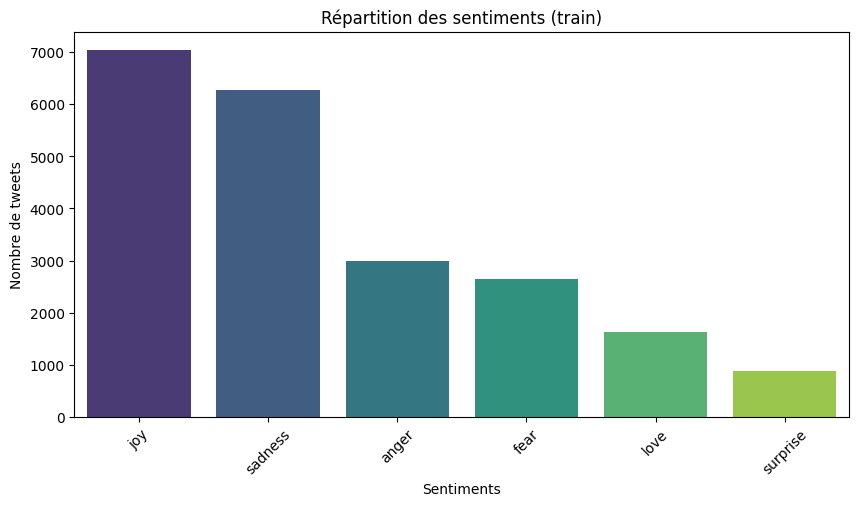

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x=emotion_train.index, y=emotion_train.values, palette="viridis")
plt.title("Répartition des sentiments (train)")
plt.ylabel("Nombre de tweets")
plt.xlabel("Sentiments")
plt.xticks(rotation=45)
plt.show()

C:\Users\anton\AppData\Local\Temp\ipykernel_10032\49378676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_test.index, y=emotion_test.values, palette="viridis")


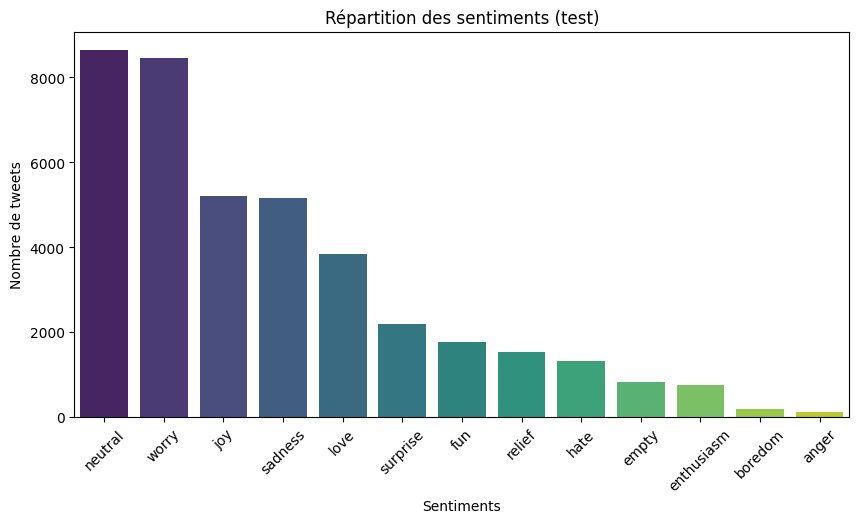

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x=emotion_test.index, y=emotion_test.values, palette="viridis")
plt.title("Répartition des sentiments (test)")
plt.ylabel("Nombre de tweets")
plt.xlabel("Sentiments")
plt.xticks(rotation=45)
plt.show()

In [18]:
from wordcloud import WordCloud

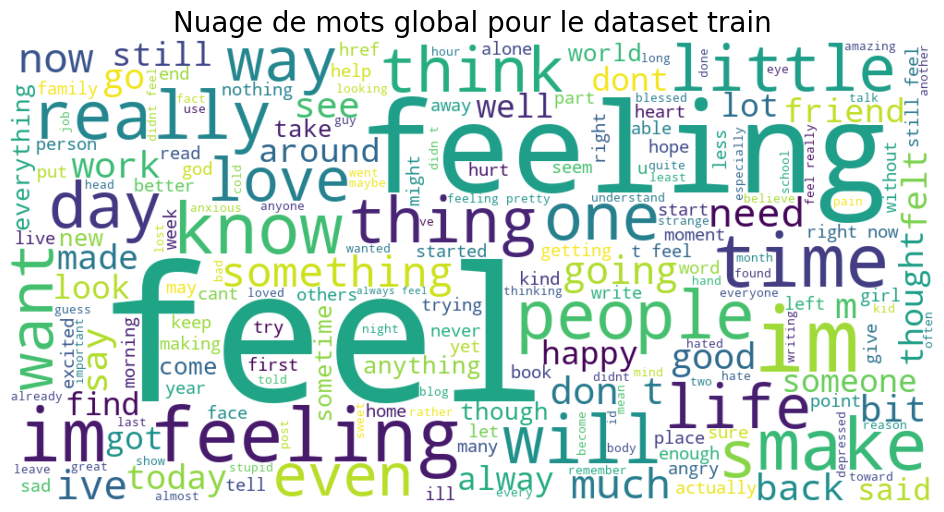

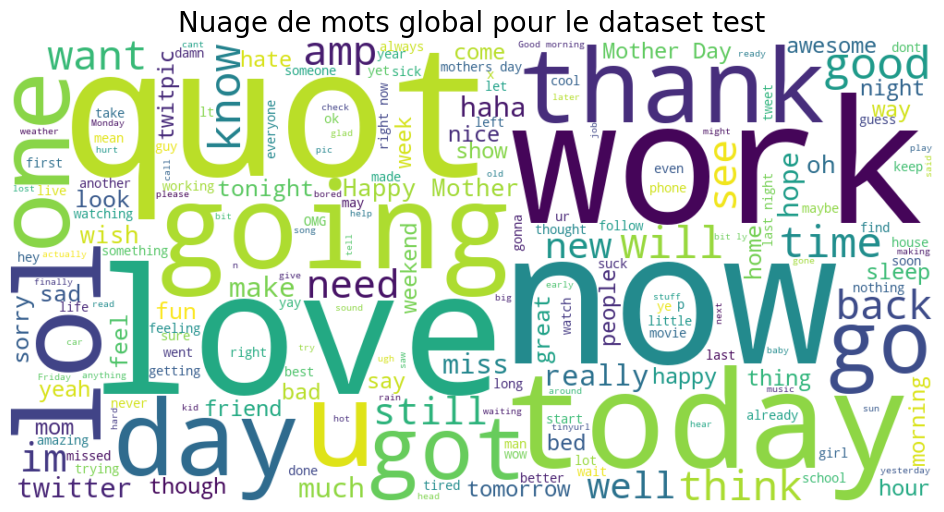

In [19]:
def plot_wordcloud_global(df, text_col, dataset_name):
    text = " ".join(df[text_col].astype(str))

    wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Nuage de mots global pour le dataset {dataset_name}", fontsize=20)
    plt.show()

plot_wordcloud_global(train, text_col='Text', dataset_name='train')

plot_wordcloud_global(test, text_col='content', dataset_name='test')

